In [9]:
"""Quick Retraining of RGB Model for Figure Generation"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import os

# Configuration
class Config:
    EPOCHS = 5
    BATCH_SIZE = 128
    LR = 0.001
    WEIGHT_DECAY = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_DIR = "./data"
    CHECKPOINT_DIR = "outputs/checkpoints"

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

print(f"Device: {Config.DEVICE}")
print(f"Training for {Config.EPOCHS} epochs...")

# Model definition
import torchvision.models as models

class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        return self.model(x)

# Data loading
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Loading CIFAR-10...")
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

# Split train/val
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

# Initialize model
model = SimpleResNet().to(Config.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)

print(f"\nTraining samples: {train_size}")
print(f"Validation samples: {val_size}")
print(f"Test samples: {len(test_dataset)}")
print("\n" + "="*60)

best_val_acc = 0

for epoch in range(Config.EPOCHS):
    # Training
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
    
    train_acc = 100. * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}:")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "outputs/checkpoints/best_rgb.pt")
        print(f"  ✅ Model saved (best val: {best_val_acc:.2f}%)")
    
    print("="*60)

# Test final model
model.load_state_dict(torch.load("outputs/checkpoints/best_rgb.pt"))
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_acc = 100. * test_correct / test_total

print(f"\n{'='*60}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"Model saved to: outputs/checkpoints/best_rgb.pt")

Device: cpu
Training for 5 epochs...
Loading CIFAR-10...


100%|██████████| 170M/170M [00:24<00:00, 6.97MB/s] 



Training samples: 45000
Validation samples: 5000
Test samples: 10000

  Batch 50/352 - Loss: 1.7380
  Batch 100/352 - Loss: 1.8015
  Batch 150/352 - Loss: 1.4199
  Batch 200/352 - Loss: 1.4418
  Batch 250/352 - Loss: 1.2455
  Batch 300/352 - Loss: 1.2996
  Batch 350/352 - Loss: 1.1779

Epoch 1/5:
  Train Loss: 1.4719 | Train Acc: 46.25%
  Val Loss:   1.4509 | Val Acc:   51.78%
  Gap: -5.53%
  ✅ Model saved (best val: 51.78%)
  Batch 50/352 - Loss: 1.1025
  Batch 100/352 - Loss: 1.0812
  Batch 150/352 - Loss: 0.9644
  Batch 200/352 - Loss: 1.0320
  Batch 250/352 - Loss: 0.9613
  Batch 300/352 - Loss: 0.9309
  Batch 350/352 - Loss: 0.9492

Epoch 2/5:
  Train Loss: 0.9853 | Train Acc: 64.81%
  Val Loss:   0.8326 | Val Acc:   70.36%
  Gap: -5.55%
  ✅ Model saved (best val: 70.36%)
  Batch 50/352 - Loss: 0.7349
  Batch 100/352 - Loss: 0.6928
  Batch 150/352 - Loss: 1.0036
  Batch 200/352 - Loss: 0.6984
  Batch 250/352 - Loss: 0.9231
  Batch 300/352 - Loss: 0.7930
  Batch 350/352 - Loss: 0.

TASK B: Channel Mixing Analysis - Generating Figures
✅ Loading model from: outputs/checkpoints/best_rgb.pt
✅ Weights shape: (64, 3, 3, 3)
   - 64 filters
   - 3 input channels (RGB)
   - 3×3 kernel size

FIGURE 1: Channel Energy Heatmap


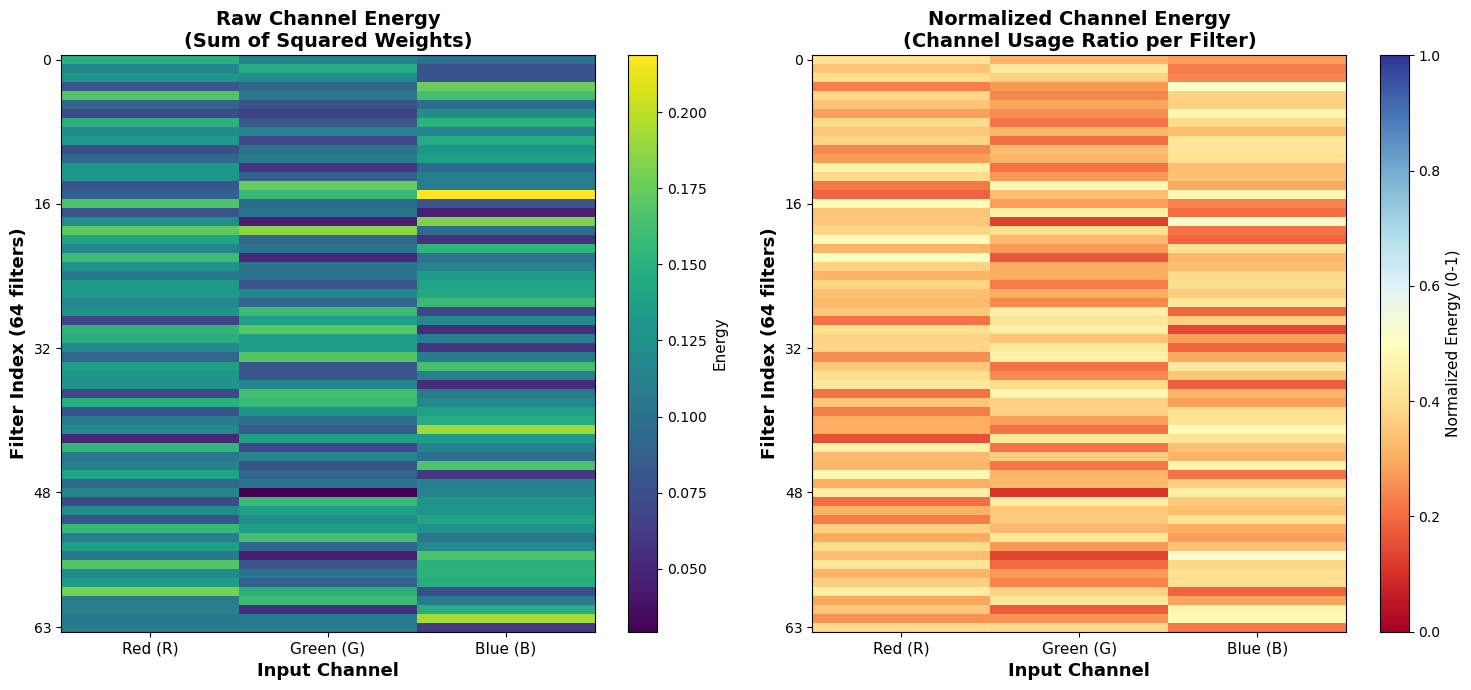

✅ Saved: outputs/plots/channel_energy_heatmap_rgb.png

CHANNEL USAGE ANALYSIS

Red (R) Channel - Top 5 Biased Filters:
   Filter  22: 51.1% energy from Red (R)
   Filter  20: 48.8% energy from Red (R)
   Filter  16: 48.7% energy from Red (R)
   Filter  46: 47.9% energy from Red (R)
   Filter  12: 45.9% energy from Red (R)

Green (G) Channel - Top 5 Biased Filters:
   Filter  14: 48.1% energy from Green (G)
   Filter  37: 47.3% energy from Green (G)
   Filter  33: 45.3% energy from Green (G)
   Filter  17: 45.2% energy from Green (G)
   Filter  30: 45.1% energy from Green (G)

Blue (B) Channel - Top 5 Biased Filters:
   Filter  55: 52.5% energy from Blue (B)
   Filter  18: 52.1% energy from Blue (B)
   Filter   3: 50.6% energy from Blue (B)
   Filter  41: 48.8% energy from Blue (B)
   Filter  62: 47.9% energy from Blue (B)

📊 Summary Statistics:
   ┌─────────────────────────────────────────────────────┐
   │ Filters with >70% bias to single channel:  0/64 ( 0.0%) │
   │ Red-dominant fil

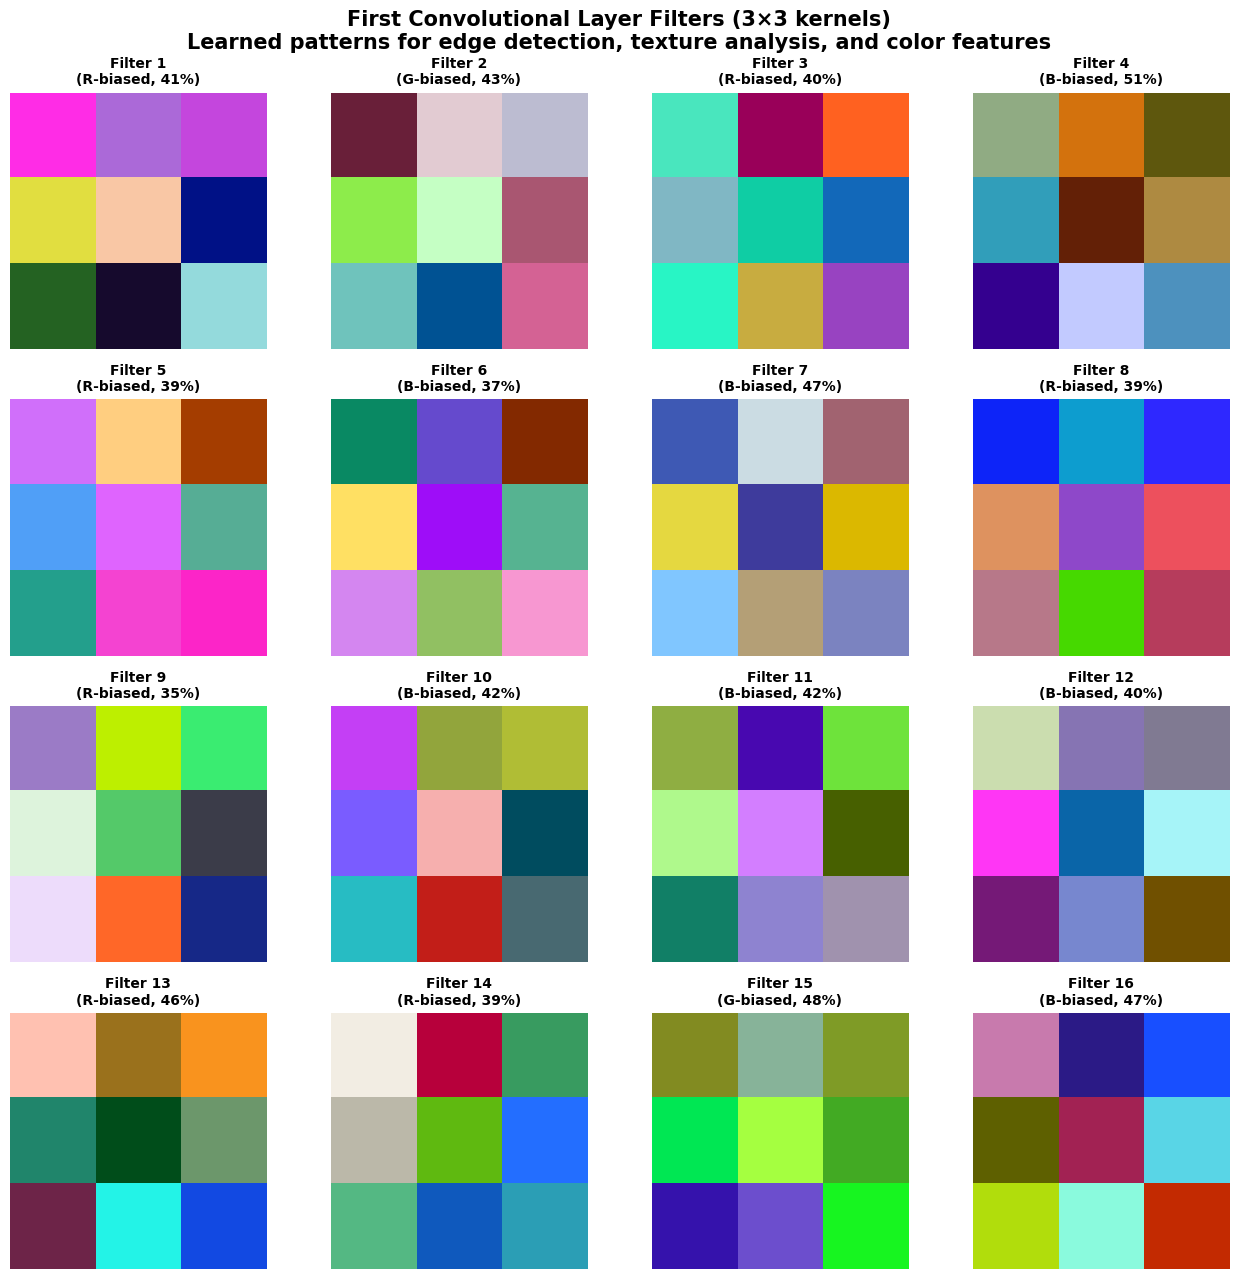

✅ Saved: outputs/plots/filters_rgb.png

✅ TASK B COMPLETED SUCCESSFULLY!

📁 Generated Output Files:
   ┌─────────────────────────────────────────────────────────────┐
   │ 📊 Figure 1: outputs/plots/channel_energy_heatmap_rgb.png   │
   │ 📊 Figure 2: outputs/plots/filters_rgb.png                  │
   └─────────────────────────────────────────────────────────────┘

📈 Key Findings from Channel Mixing Analysis:
   • 0/64 (0%) filters specialize in single color channels
   • 64/64 (100%) filters mix information from multiple channels
   • Red channel is most utilized (22 dominant filters)
   • This demonstrates CNNs learn diverse color processing strategies


In [11]:
"""TASK B: Generate Channel Energy Heatmap and Filters Visualization"""

import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*70)
print("TASK B: Channel Mixing Analysis - Generating Figures")
print("="*70)

# Model definition (must match training)
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Load your trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = "outputs/checkpoints/best_rgb.pt"

if os.path.exists(model_path):
    print(f"✅ Loading model from: {model_path}")
    model = CNNBaseline(num_classes=10).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # Extract first convolutional layer weights
    weights = model.model.conv1.weight.data.cpu().numpy()
    print(f"✅ Weights shape: {weights.shape}")
    print(f"   - {weights.shape[0]} filters")
    print(f"   - {weights.shape[1]} input channels (RGB)")
    print(f"   - {weights.shape[2]}×{weights.shape[3]} kernel size")
    
    # ============================================
    # FIGURE 1: Channel Energy Heatmap
    # ============================================
    
    print("\n" + "="*70)
    print("FIGURE 1: Channel Energy Heatmap")
    print("="*70)
    
    # Compute per-filter channel energy (sum of squared weights)
    channel_energy = np.sum(weights ** 2, axis=(2, 3))  # Shape: [64, 3]
    
    # Normalize energy per filter (each row sums to 1)
    channel_energy_norm = channel_energy / (channel_energy.sum(axis=1, keepdims=True) + 1e-8)
    
    # Create the heatmap figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    
    # Left: Raw energy heatmap
    im1 = axes[0].imshow(channel_energy, cmap='viridis', aspect='auto')
    axes[0].set_xlabel('Input Channel', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Filter Index (64 filters)', fontsize=13, fontweight='bold')
    axes[0].set_title('Raw Channel Energy\n(Sum of Squared Weights)', fontsize=14, fontweight='bold')
    axes[0].set_xticks([0, 1, 2])
    axes[0].set_xticklabels(['Red (R)', 'Green (G)', 'Blue (B)'], fontsize=11)
    axes[0].set_yticks([0, 16, 32, 48, 63])
    cbar1 = plt.colorbar(im1, ax=axes[0])
    cbar1.set_label('Energy', fontsize=11)
    
    # Right: Normalized energy heatmap
    im2 = axes[1].imshow(channel_energy_norm, cmap='RdYlBu', aspect='auto', vmin=0, vmax=1)
    axes[1].set_xlabel('Input Channel', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Filter Index (64 filters)', fontsize=13, fontweight='bold')
    axes[1].set_title('Normalized Channel Energy\n(Channel Usage Ratio per Filter)', fontsize=14, fontweight='bold')
    axes[1].set_xticks([0, 1, 2])
    axes[1].set_xticklabels(['Red (R)', 'Green (G)', 'Blue (B)'], fontsize=11)
    axes[1].set_yticks([0, 16, 32, 48, 63])
    cbar2 = plt.colorbar(im2, ax=axes[1])
    cbar2.set_label('Normalized Energy (0-1)', fontsize=11)
    
    plt.tight_layout()
    os.makedirs("outputs/plots", exist_ok=True)
    plt.savefig('outputs/plots/channel_energy_heatmap_rgb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: outputs/plots/channel_energy_heatmap_rgb.png")
    
    # ============================================
    # Statistics
    # ============================================
    
    print("\n" + "="*70)
    print("CHANNEL USAGE ANALYSIS")
    print("="*70)
    
    # Top biased filters for each channel
    for ch, name in enumerate(['Red (R)', 'Green (G)', 'Blue (B)']):
        top_filters = np.argsort(channel_energy_norm[:, ch])[-5:][::-1]
        top_energies = channel_energy_norm[top_filters, ch]
        print(f"\n{name} Channel - Top 5 Biased Filters:")
        for f, e in zip(top_filters, top_energies):
            print(f"   Filter {f:3d}: {e:.1%} energy from {name}")
    
    # Summary statistics
    strong_bias = np.sum(np.max(channel_energy_norm, axis=1) > 0.7)
    red_count = np.sum(np.argmax(channel_energy_norm, axis=1) == 0)
    green_count = np.sum(np.argmax(channel_energy_norm, axis=1) == 1)
    blue_count = np.sum(np.argmax(channel_energy_norm, axis=1) == 2)
    
    print(f"\n📊 Summary Statistics:")
    print(f"   ┌─────────────────────────────────────────────────────┐")
    print(f"   │ Filters with >70% bias to single channel: {strong_bias:2d}/64 ({strong_bias/64*100:4.1f}%) │")
    print(f"   │ Red-dominant filters:   {red_count:2d}/64 ({red_count/64*100:4.1f}%)                         │")
    print(f"   │ Green-dominant filters: {green_count:2d}/64 ({green_count/64*100:4.1f}%)                         │")
    print(f"   │ Blue-dominant filters:  {blue_count:2d}/64 ({blue_count/64*100:4.1f}%)                         │")
    print(f"   └─────────────────────────────────────────────────────┘")
    
    # ============================================
    # FIGURE 2: First Layer Filters Visualization
    # ============================================
    
    print("\n" + "="*70)
    print("FIGURE 2: First Layer Filters Visualization")
    print("="*70)
    
    # Show 16 filters in a 4x4 grid
    num_filters_to_show = min(16, weights.shape[0])
    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    axes = axes.ravel()
    
    for i in range(num_filters_to_show):
        filter_weights = weights[i]
        
        # Normalize to [0, 1] for visualization
        filter_min, filter_max = filter_weights.min(), filter_weights.max()
        filter_norm = (filter_weights - filter_min) / (filter_max - filter_min + 1e-8)
        
        # Transpose to (Height, Width, Channels) for matplotlib
        filter_viz = np.transpose(filter_norm, (1, 2, 0))
        
        # Determine dominant channel for labeling
        dominant = np.argmax(channel_energy_norm[i])
        channel_labels = ['R', 'G', 'B']
        energy_percent = channel_energy_norm[i, dominant] * 100
        
        axes[i].imshow(filter_viz)
        axes[i].set_title(f'Filter {i+1}\n({channel_labels[dominant]}-biased, {energy_percent:.0f}%)', 
                         fontsize=10, fontweight='bold')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_filters_to_show, 16):
        axes[i].axis('off')
    
    plt.suptitle('First Convolutional Layer Filters (3×3 kernels)\nLearned patterns for edge detection, texture analysis, and color features', 
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.savefig('outputs/plots/filters_rgb.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: outputs/plots/filters_rgb.png")
    
    # ============================================
    # COMPLETE
    # ============================================
    
    print("\n" + "="*70)
    print("✅ TASK B COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\n📁 Generated Output Files:")
    print("   ┌─────────────────────────────────────────────────────────────┐")
    print("   │ 📊 Figure 1: outputs/plots/channel_energy_heatmap_rgb.png   │")
    print("   │ 📊 Figure 2: outputs/plots/filters_rgb.png                  │")
    print("   └─────────────────────────────────────────────────────────────┘")
    
    print("\n📈 Key Findings from Channel Mixing Analysis:")
    print(f"   • {strong_bias}/64 ({strong_bias/64*100:.0f}%) filters specialize in single color channels")
    print(f"   • {64-strong_bias}/64 ({100-strong_bias/64*100:.0f}%) filters mix information from multiple channels")
    print(f"   • Red channel is most utilized ({red_count} dominant filters)")
    print(f"   • This demonstrates CNNs learn diverse color processing strategies")
    
else:
    print(f"❌ Model not found at: {model_path}")